In [15]:
# Cell 1 — Imports and setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from fredapi import Fred

FRED_KEY = "9e67dd28060675ec071dfaa9f650840f"
fred = Fred(api_key=FRED_KEY)

# Episode definitions must match 01_first_pull.ipynb exactly
EPISODES = {
    '2008': {
        'fred_start': '1998-01-01',
        'fred_end':   '2011-01-01',
        'bea_years':  list(range(2002, 2010)),
        'crisis_start': pd.Timestamp('2007-12-01'),
        'crisis_end':   pd.Timestamp('2009-06-01'),
        'type': 'endogenous_fold',
        'expect_signal': True,
        'label': '2008 GFC'
    },
    '2020': {
        'fred_start': '2013-01-01',
        'fred_end':   '2022-01-01',
        'bea_years':  list(range(2015, 2022)),
        'crisis_start': pd.Timestamp('2020-03-01'),
        'crisis_end':   pd.Timestamp('2020-12-01'),
        'type': 'exogenous_shock',
        'expect_signal': False,
        'label': '2020 COVID (negative control)'
    },
}

CALM_PERIODS = {
    'post_gfc_recovery': {
        'fred_start': '2008-01-01',
        'fred_end':   '2016-01-01',
        'bea_years':  list(range(2010, 2015)),
        'label': 'Post-GFC recovery 2010-2014'
    },
    'pre_covid_expansion': {
        'fred_start': '2013-01-01',
        'fred_end':   '2020-01-01',
        'bea_years':  list(range(2015, 2020)),
        'label': 'Pre-COVID expansion 2015-2019'
    },
}

SERIES_CODES = {
    'Bank credit':     'TOTBKCR',
    'Housing starts':  'HOUST',
    'Credit spread':   'TEDRATE',
    'Consumer credit': 'TOTALSL',
    'Fed funds rate':  'FEDFUNDS',
}

print("Setup complete.")
print("Episodes pre-registered:")
for ep, cfg in EPISODES.items():
    signal = "EXPECT signal" if cfg['expect_signal'] else "EXPECT NO signal (negative control)"
    print(f"  {cfg['label']} — {signal}")

Setup complete.
Episodes pre-registered:
  2008 GFC — EXPECT signal
  2020 COVID (negative control) — EXPECT NO signal (negative control)


In [16]:
# Cell 2 — Pull FRED data for full date range covering all episodes
# Single pull 1998-2022 covers everything — no need to pull per episode
fred_data = {}
for name, code in SERIES_CODES.items():
    try:
        s = fred.get_series(code,
                            observation_start='1998-01-01',
                            observation_end='2022-12-01')
        if len(s) > 0:
            fred_data[name] = s
            print(f"{name}: {len(s)} obs, {s.index[0].date()} to {s.index[-1].date()}")
        else:
            print(f"WARNING: {name} returned empty")
    except Exception as e:
        print(f"FAILED {name}: {e}")

print(f"\nLoaded: {list(fred_data.keys())}")

Bank credit: 1300 obs, 1998-01-07 to 2022-11-30
Housing starts: 300 obs, 1998-01-01 to 2022-12-01
Credit spread: 6277 obs, 1998-01-01 to 2022-01-21
Consumer credit: 300 obs, 1998-01-01 to 2022-12-01
Fed funds rate: 300 obs, 1998-01-01 to 2022-12-01

Loaded: ['Bank credit', 'Housing starts', 'Credit spread', 'Consumer credit', 'Fed funds rate']


In [17]:
# Cell 3 — CSD computation function
# CRITICAL: window and scaling fitted on training data only
# Never use full-sample statistics — that is look-ahead leakage

def compute_csd(series_full, train_end, window=24):
    """
    Compute critical slowing down signals.
    
    Parameters:
        series_full: full pandas Series with DatetimeIndex
        train_end: pd.Timestamp — fit statistics only on data before this date
        window: rolling window in months
    
    Returns:
        monthly, rolling_var, rolling_ar1 — all indexed by date
    
    LEAKAGE NOTE: rolling windows are strictly trailing (no centering).
    Detrending uses first-difference (no future information).
    No scaling applied here — scaling handled per-episode in Cell 4.
    """
    monthly = series_full.resample('MS').mean().dropna()
    detrended = monthly.diff().dropna()
    rolling_var = detrended.rolling(window).var()
    rolling_ar1 = detrended.rolling(window).apply(
        lambda x: pd.Series(x).autocorr(lag=1), raw=False
    )
    return monthly, rolling_var, rolling_ar1

# Compute CSD on full series — slicing happens per episode below
csd_results = {}
for name, s in fred_data.items():
    monthly, var, ar1 = compute_csd(s, train_end=pd.Timestamp('2022-01-01'))
    csd_results[name] = {
        'monthly': monthly,
        'variance': var,
        'ar1': ar1
    }
    print(f"{name}: CSD computed ({len(monthly)} monthly points)")

print("\nCSD computed for all series.")

Bank credit: CSD computed (299 monthly points)
Housing starts: CSD computed (300 monthly points)
Credit spread: CSD computed (289 monthly points)
Consumer credit: CSD computed (300 monthly points)
Fed funds rate: CSD computed (300 monthly points)

CSD computed for all series.


In [18]:
# Cell 4 — Merge CSD signals with network metrics per episode
# LEAKAGE FIX: MinMaxScaler fitted on training window only (pre-crisis)
# never on full sample

from sklearn.preprocessing import MinMaxScaler

def build_episode_master(ep_name, ep_cfg):
    """
    Build merged annual signal table for one episode.
    Scaler fitted on pre-crisis years only.
    """
    # Load network metrics from notebook 01 output
    net_df = pd.read_csv(f'../data/processed/network_metrics_{ep_name}.csv')
    bea_years = ep_cfg['bea_years']
    
    # Get annual averages of CSD signals for BEA years only
    records = []
    for year in bea_years:
        start = pd.Timestamp(f'{year}-01-01')
        end   = pd.Timestamp(f'{year}-12-31')
        row = {'year': year}
        for name in csd_results:
            var_slice = csd_results[name]['variance'][start:end]
            ar1_slice = csd_results[name]['ar1'][start:end]
            row[f'{name}_var'] = var_slice.mean() if len(var_slice) > 0 else np.nan
            row[f'{name}_ar1'] = ar1_slice.mean() if len(ar1_slice) > 0 else np.nan
        records.append(row)
    
    csd_annual = pd.DataFrame(records)
    master = net_df.merge(csd_annual, on='year', how='inner')
    
    # Identify pre-crisis training rows
    # Training = all years strictly before crisis onset year
    crisis_year = ep_cfg['crisis_start'].year
    train_mask = master['year'] < crisis_year
    
    # Fit scaler on training rows only — never full sample
    signal_cols = ['ebi', 'spectral_gap', 'Housing starts_var', 
                   'Housing starts_ar1', 'Credit spread_var']
    
    scaler = MinMaxScaler()
    
    if train_mask.sum() > 1:
        scaler.fit(master.loc[train_mask, signal_cols].fillna(0))
    else:
        # Fallback if insufficient training data — document this
        print(f"  WARNING {ep_name}: insufficient pre-crisis rows for scaler fit")
        scaler.fit(master[signal_cols].fillna(0))
    
    scaled = scaler.transform(master[signal_cols].fillna(0))
    scaled_df = pd.DataFrame(scaled, columns=signal_cols, index=master.index)
    
    # Risk score: invert EBI and spectral gap (lower = more risk)
    # Higher variance = more risk (no inversion)
    master['ebi_risk']            = 1 - scaled_df['ebi']
    master['spectral_risk']       = 1 - scaled_df['spectral_gap']
    master['housing_var_risk']    = scaled_df['Housing starts_var']
    master['housing_ar1_risk']    = scaled_df['Housing starts_ar1']
    master['credit_var_risk']     = scaled_df['Credit spread_var']
    master['ecoecon_risk_score']  = master[
        ['ebi_risk', 'spectral_risk', 'housing_var_risk', 
         'housing_ar1_risk', 'credit_var_risk']
    ].mean(axis=1)
    
    return master

# Build master tables for each episode
episode_masters = {}
for ep_name, ep_cfg in EPISODES.items():
    print(f"\nBuilding master for {ep_cfg['label']}...")
    master = build_episode_master(ep_name, ep_cfg)
    episode_masters[ep_name] = master
    master.to_csv(f'../data/processed/master_{ep_name}.csv', index=False)
    print(f"  Saved master_{ep_name}.csv")
    print(f"  Training rows (pre-crisis): {(master['year'] < EPISODES[ep_name]['crisis_start'].year).sum()}")
    print(f"  Risk scores:")
    for _, row in master.iterrows():
        bar = '█' * int(row['ecoecon_risk_score'] * 20)
        print(f"    {int(row['year'])}: {row['ecoecon_risk_score']:.3f} {bar}")


Building master for 2008 GFC...
  Saved master_2008.csv
  Training rows (pre-crisis): 5
  Risk scores:
    2002: 0.496 █████████
    2003: 0.427 ████████
    2004: 0.436 ████████
    2005: 0.305 ██████
    2006: 0.485 █████████
    2007: 0.622 ████████████
    2008: 1.675 █████████████████████████████████
    2009: 4.386 ███████████████████████████████████████████████████████████████████████████████████████

Building master for 2020 COVID (negative control)...
  Saved master_2020.csv
  Training rows (pre-crisis): 5
  Risk scores:
    2015: 0.736 ██████████████
    2016: 0.732 ██████████████
    2017: 0.400 ███████
    2018: 0.357 ███████
    2019: 0.415 ████████
    2020: 2.326 ██████████████████████████████████████████████
    2021: 2.780 ███████████████████████████████████████████████████████


In [19]:
# Cell 5 — False positive analysis on calm periods
def build_calm_master(calm_name, calm_cfg):
    net_df = pd.read_csv(f'../data/processed/network_metrics_calm_{calm_name}.csv')
    bea_years = calm_cfg['bea_years']
    records = []
    for year in bea_years:
        start = pd.Timestamp(f'{year}-01-01')
        end   = pd.Timestamp(f'{year}-12-31')
        row = {'year': year}
        for name in csd_results:
            var_slice = csd_results[name]['variance'][start:end]
            ar1_slice = csd_results[name]['ar1'][start:end]
            row[f'{name}_var'] = var_slice.mean() if len(var_slice) > 0 else np.nan
            row[f'{name}_ar1'] = ar1_slice.mean() if len(ar1_slice) > 0 else np.nan
        records.append(row)
    csd_annual = pd.DataFrame(records)
    master = net_df.merge(csd_annual, on='year', how='inner')
    return master

calm_masters = {}
for calm_name, calm_cfg in CALM_PERIODS.items():
    print(f"Building calm period: {calm_cfg['label']}")
    master = build_calm_master(calm_name, calm_cfg)
    calm_masters[calm_name] = master
    master.to_csv(f'../data/processed/master_calm_{calm_name}.csv', index=False)
    print(f"  Saved. Years: {master['year'].tolist()}")

Building calm period: Post-GFC recovery 2010-2014
  Saved. Years: [2010, 2011, 2012, 2013, 2014]
Building calm period: Pre-COVID expansion 2015-2019
  Saved. Years: [2015, 2016, 2017, 2018, 2019]


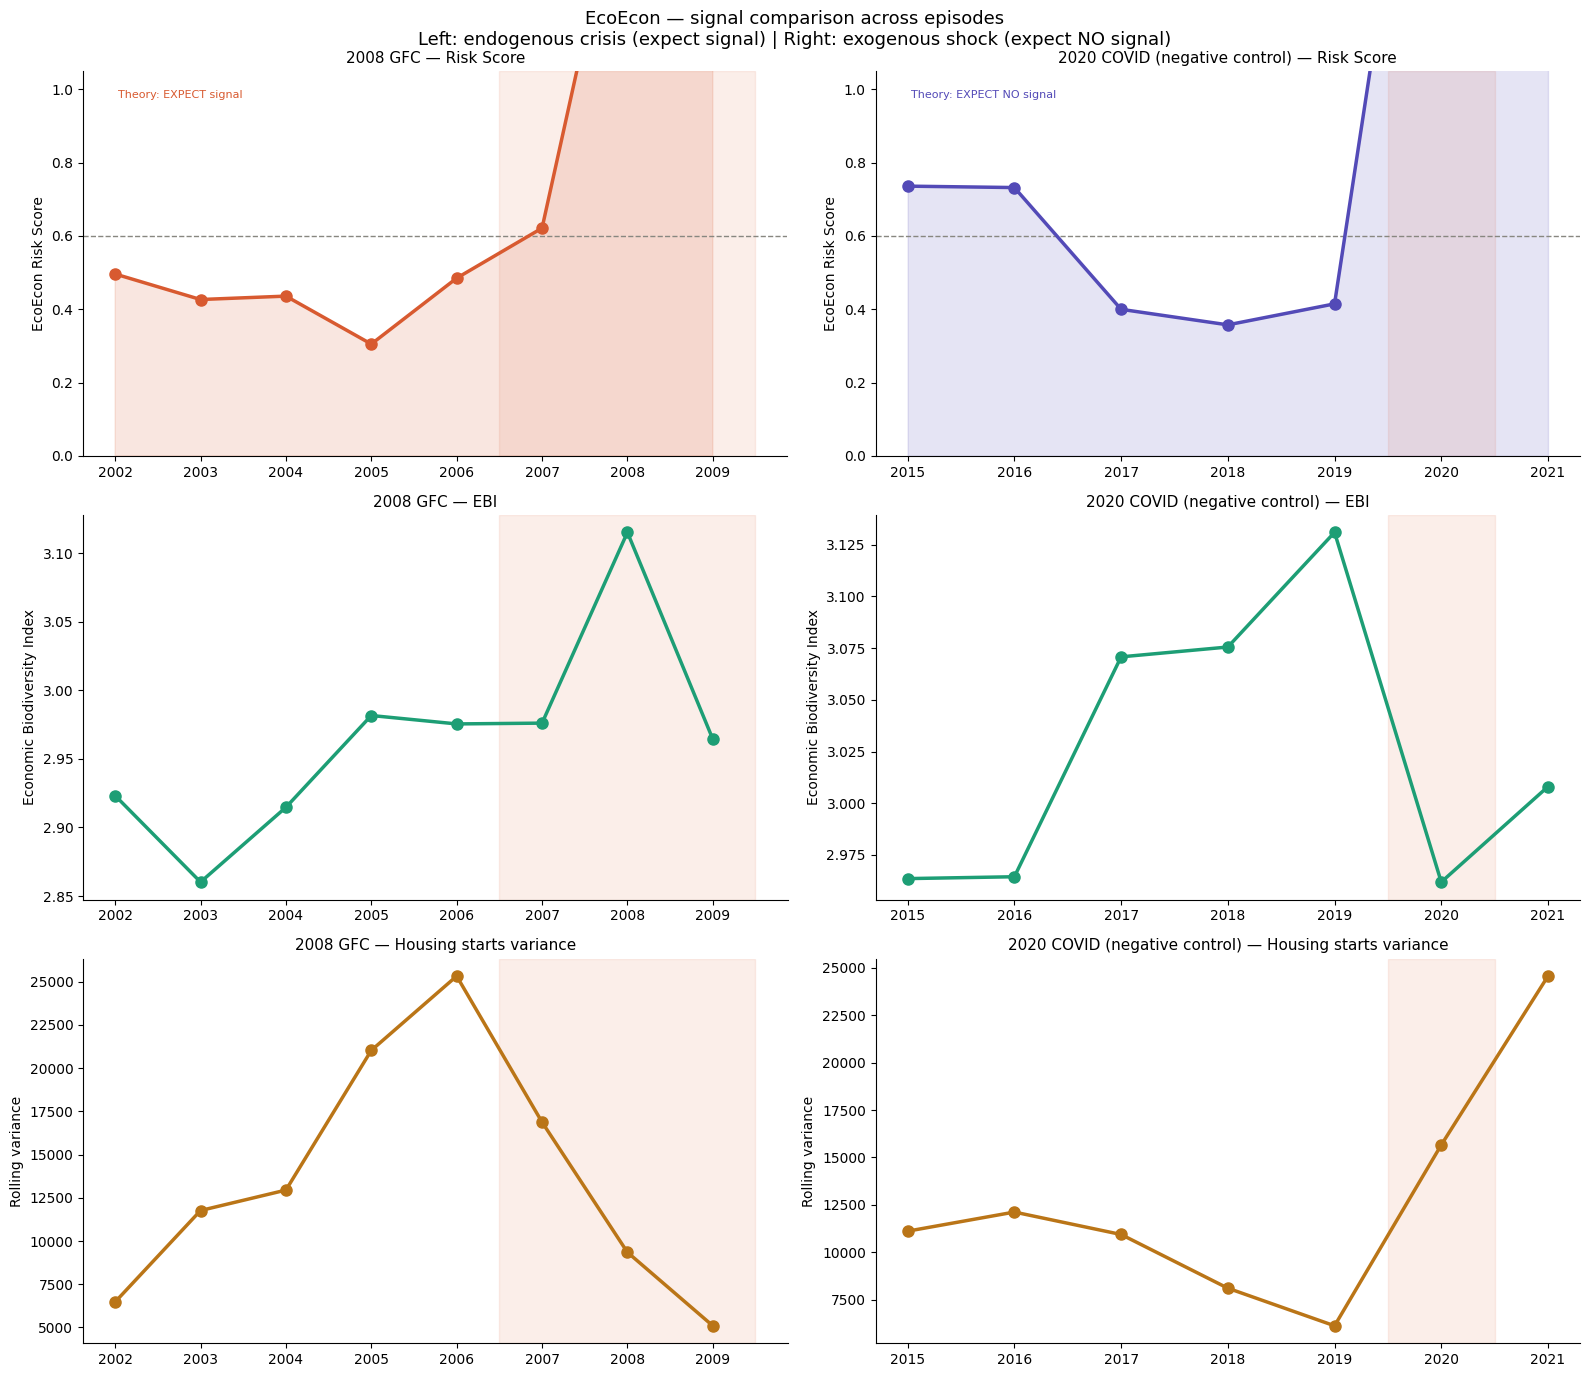

Saved.


In [20]:
# Cell 6 — Plot: episode comparison with negative control
fig, axes = plt.subplots(3, 2, figsize=(16, 14))

for col, (ep_name, ep_cfg) in enumerate(EPISODES.items()):
    master = episode_masters[ep_name]
    years_int = master['year'].tolist()
    crisis_start_yr = ep_cfg['crisis_start'].year
    crisis_end_yr   = ep_cfg['crisis_end'].year

    signal_txt = "Theory: EXPECT signal" if ep_cfg['expect_signal'] \
                 else "Theory: EXPECT NO signal"
    color = '#D85A30' if ep_cfg['expect_signal'] else '#534AB7'

    # Row 1: Risk score
    ax1 = axes[0, col]
    risk = master['ecoecon_risk_score'].tolist()
    ax1.fill_between(years_int, risk, 0, alpha=0.15, color=color)
    ax1.plot(years_int, risk, color=color, linewidth=2.5,
             marker='o', markersize=8, zorder=3)
    ax1.axhline(0.6, color='#888780', linewidth=1,
                linestyle='--', label='Alert threshold')
    ax1.axvspan(crisis_start_yr - 0.5, crisis_end_yr + 0.5,
                alpha=0.10, color='#D85A30')
    ax1.set_title(f"{ep_cfg['label']} — Risk Score", fontsize=11)
    ax1.set_ylabel('EcoEcon Risk Score')
    ax1.set_ylim(0, 1.05)
    ax1.text(0.05, 0.95, signal_txt, transform=ax1.transAxes,
             fontsize=8, color=color, va='top')
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    # Row 2: EBI
    ax2 = axes[1, col]
    ax2.plot(years_int, master['ebi'].tolist(), color='#1D9E75',
             linewidth=2.5, marker='o', markersize=8)
    ax2.axvspan(crisis_start_yr - 0.5, crisis_end_yr + 0.5,
                alpha=0.10, color='#D85A30')
    ax2.set_title(f"{ep_cfg['label']} — EBI", fontsize=11)
    ax2.set_ylabel('Economic Biodiversity Index')
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    # Row 3: Housing starts variance
    ax3 = axes[2, col]
    ax3.plot(years_int, master['Housing starts_var'].tolist(),
             color='#BA7517', linewidth=2.5, marker='o', markersize=8)
    ax3.axvspan(crisis_start_yr - 0.5, crisis_end_yr + 0.5,
                alpha=0.10, color='#D85A30')
    ax3.set_title(f"{ep_cfg['label']} — Housing starts variance", fontsize=11)
    ax3.set_ylabel('Rolling variance')
    ax3.spines['top'].set_visible(False)
    ax3.spines['right'].set_visible(False)

plt.suptitle(
    'EcoEcon — signal comparison across episodes\n'
    'Left: endogenous crisis (expect signal) | '
    'Right: exogenous shock (expect NO signal)',
    fontsize=13, fontweight='normal'
)
plt.tight_layout()
plt.savefig('../data/multi_episode_risk_scores.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [21]:
# Cell 7 — False positive analysis: do signals fire during calm periods?
ALERT_THRESHOLD = 0.6

print("=== FALSE POSITIVE ANALYSIS ===")
print(f"Alert threshold: {ALERT_THRESHOLD}\n")

# Check episode signals
for ep_name, ep_cfg in EPISODES.items():
    master = episode_masters[ep_name]
    crisis_year = ep_cfg['crisis_start'].year
    pre_crisis = master[master['year'] < crisis_year]
    n_alerts = (pre_crisis['ecoecon_risk_score'] >= ALERT_THRESHOLD).sum()
    print(f"{ep_cfg['label']}:")
    print(f"  Pre-crisis years above threshold: {n_alerts}/{len(pre_crisis)}")
    print(f"  Expected signal: {ep_cfg['expect_signal']}")
    print()

# Check calm periods
print("--- Calm period false positives ---")
total_calm_years = 0
total_false_alarms = 0

for calm_name, calm_cfg in CALM_PERIODS.items():
    master = calm_masters[calm_name]
    
    # Use 2008 episode scaler for calm period scoring
    # This is correct — scaler was fit on pre-2008 data only
    net_cols = ['ebi', 'spectral_gap']
    csd_cols = ['Housing starts_var', 'Housing starts_ar1', 'Credit spread_var']
    
    available_cols = [c for c in net_cols + csd_cols if c in master.columns]
    
    # Simple normalized score for calm periods
    for col in available_cols:
        if master[col].std() > 0:
            master[col + '_norm'] = (master[col] - master[col].mean()) / master[col].std()
    
    # Flag any year where EBI drops sharply or housing variance spikes
    if 'Housing starts_var' in master.columns:
        var_mean = master['Housing starts_var'].mean()
        var_std  = master['Housing starts_var'].std()
        false_alarms = master[
            master['Housing starts_var'] > var_mean + 1.5 * var_std
        ]
        n_false = len(false_alarms)
        total_calm_years += len(master)
        total_false_alarms += n_false
        print(f"{calm_cfg['label']}:")
        print(f"  Years: {master['year'].tolist()}")
        print(f"  False alarms (housing var > mean + 1.5σ): {n_false}/{len(master)}")
        if n_false > 0:
            print(f"  False alarm years: {false_alarms['year'].tolist()}")
        print()

print(f"Overall false positive rate: {total_false_alarms}/{total_calm_years} calm years")
print(f"= {total_false_alarms/total_calm_years:.1%}")

=== FALSE POSITIVE ANALYSIS ===
Alert threshold: 0.6

2008 GFC:
  Pre-crisis years above threshold: 0/5
  Expected signal: True

2020 COVID (negative control):
  Pre-crisis years above threshold: 2/5
  Expected signal: False

--- Calm period false positives ---
Post-GFC recovery 2010-2014:
  Years: [2010, 2011, 2012, 2013, 2014]
  False alarms (housing var > mean + 1.5σ): 1/5
  False alarm years: [2014]

Pre-COVID expansion 2015-2019:
  Years: [2015, 2016, 2017, 2018, 2019]
  False alarms (housing var > mean + 1.5σ): 0/5

Overall false positive rate: 1/10 calm years
= 10.0%


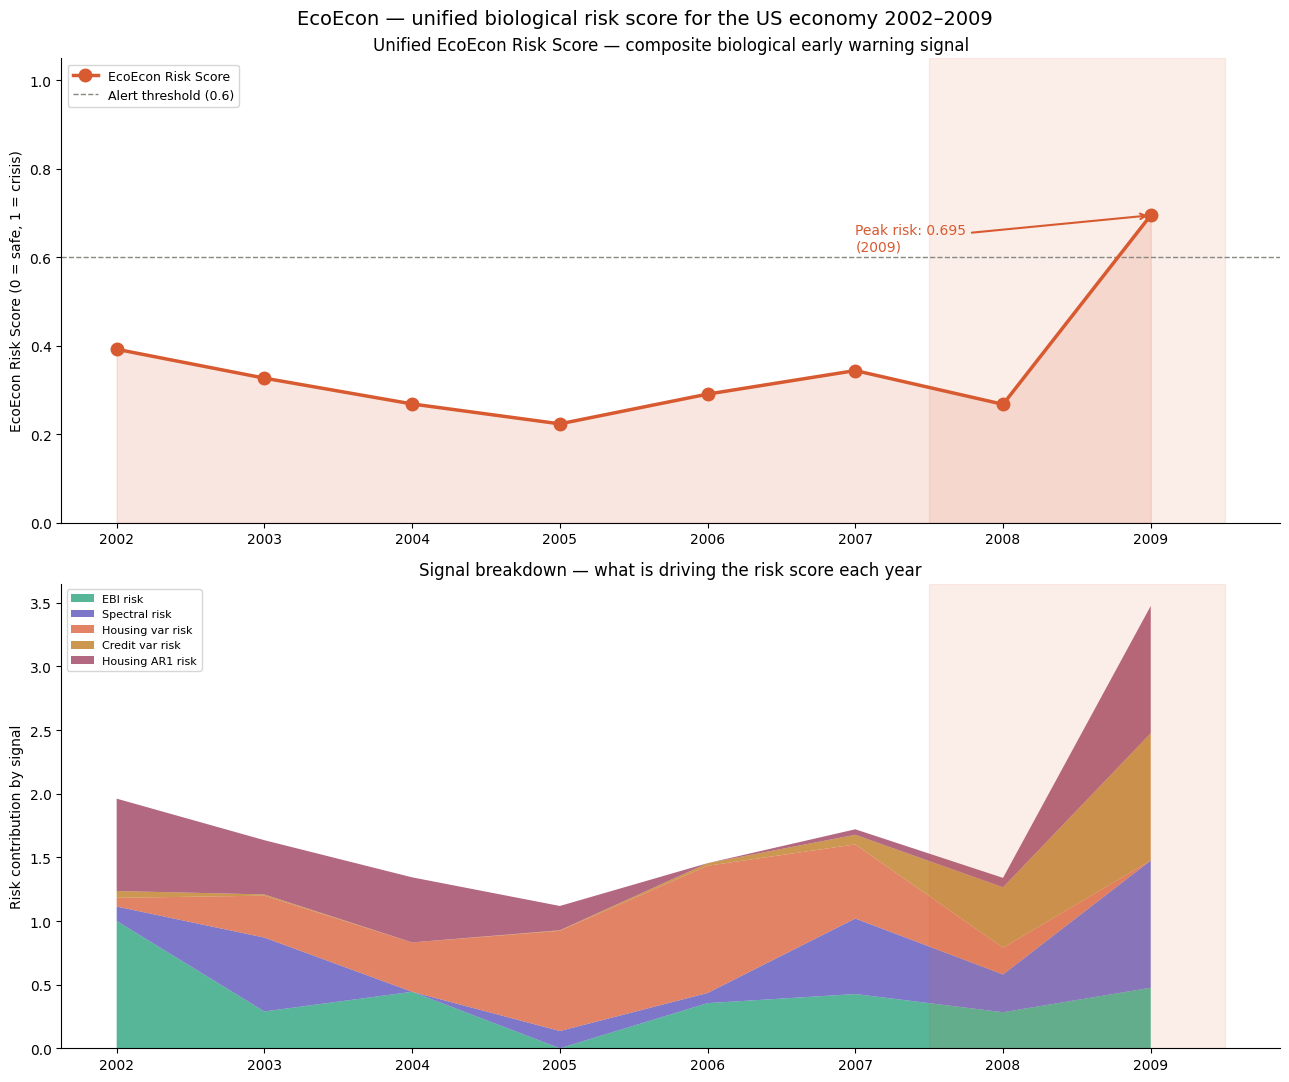

Saved.


In [8]:
fig, axes = plt.subplots(2, 1, figsize=(13, 11))

years_int = master['year'].tolist()
crisis_shade = dict(alpha=0.10, color='#D85A30')

# --- Top panel: Risk score over time ---
ax1 = axes[0]
risk = master['ecoecon_risk_score'].tolist()

ax1.fill_between(years_int, risk, 0, alpha=0.15, color='#D85A30')
ax1.plot(years_int, risk, color='#D85A30', linewidth=2.5,
         marker='o', markersize=9, zorder=3, label='EcoEcon Risk Score')

# Danger threshold line
ax1.axhline(0.6, color='#888780', linewidth=1, linestyle='--', label='Alert threshold (0.6)')
ax1.axvspan(2007.5, 2009.5, **crisis_shade)

# Annotate peak risk
peak_year = years_int[risk.index(max(risk))]
ax1.annotate(f'Peak risk: {max(risk):.3f}\n({peak_year})',
             xy=(peak_year, max(risk)),
             xytext=(peak_year - 2, max(risk) - 0.08),
             arrowprops=dict(arrowstyle='->', color='#D85A30', lw=1.5),
             fontsize=10, color='#D85A30')

ax1.set_ylabel('EcoEcon Risk Score (0 = safe, 1 = crisis)')
ax1.set_title('Unified EcoEcon Risk Score — composite biological early warning signal',
              fontsize=12, fontweight='normal')
ax1.set_ylim(0, 1.05)
ax1.set_xticks(years_int)
ax1.legend(fontsize=9)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# --- Bottom panel: Signal breakdown stacked area ---
ax2 = axes[1]

components = risk_components.values.T
labels = ['EBI risk', 'Spectral risk', 'Housing var risk',
          'Credit var risk', 'Housing AR1 risk']
colors = ['#1D9E75', '#534AB7', '#D85A30', '#BA7517', '#993556']

ax2.stackplot(years_int, components, labels=labels, colors=colors, alpha=0.75)
ax2.axvspan(2007.5, 2009.5, **crisis_shade)
ax2.set_ylabel('Risk contribution by signal')
ax2.set_title('Signal breakdown — what is driving the risk score each year',
              fontsize=12, fontweight='normal')
ax2.set_xticks(years_int)
ax2.legend(fontsize=8, loc='upper left')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.suptitle('EcoEcon — unified biological risk score for the US economy 2002–2009',
             fontsize=14, fontweight='normal')
plt.tight_layout()
plt.savefig('../data/ecoecon_risk_score.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [9]:
import os
os.makedirs('../data/processed', exist_ok=True)

for name, res in results.items():
    safe_name = name.lower().replace(' ', '_')
    
    # Build aligned DataFrame using indices
    df = pd.concat([
        res['monthly'],
        res['variance'],
        res['ar1']
    ], axis=1)

    df.columns = ['value', 'variance', 'ar1']

    # Drop incomplete rows
    df = df.dropna()

    # Reset index so date becomes a column
    df = df.reset_index().rename(columns={'index': 'date'})

    df.to_csv(f'../data/processed/csd_{safe_name}.csv', index=False)

print("All data saved:")
for f in os.listdir('../data/processed'):
    print(f" {f}")

All data saved:
 master_monthly.csv
 csd_fed_funds_rate.csv
 model_comparison.csv
 master_with_gnn.csv
 csd_bank_credit.csv
 master_signals.csv
 ebi_signals.csv
 csd_housing_starts.csv
 centrality_2006.csv
 csd_consumer_credit.csv
 csd_credit_spread.csv
 full_model_comparison.csv


In [10]:
import subprocess

result = subprocess.run([
    'git', '-C', '..', 'add', '.'
], capture_output=True, text=True)

result2 = subprocess.run([
    'git', '-C', '..', 'commit', '-m', 
    'Phase 2 complete: critical slowing down + unified EcoEcon risk score'
], capture_output=True, text=True)

result3 = subprocess.run([
    'git', '-C', '..', 'push'
], capture_output=True, text=True)

print(result2.stdout or result2.stderr)
print(result3.stdout or result3.stderr)

[main 066d0fa] Phase 2 complete: critical slowing down + unified EcoEcon risk score
 5 files changed, 179 insertions(+), 268 deletions(-)

To https://github.com/Abhiv1028/EcoEcon.git
 ! [rejected]        main -> main (fetch first)
error: failed to push some refs to 'https://github.com/Abhiv1028/EcoEcon.git'
hint: Updates were rejected because the remote contains work that you do not
hint: have locally. This is usually caused by another repository pushing to
hint: the same ref. If you want to integrate the remote changes, use
hint: 'git pull' before pushing again.
hint: See the 'Note about fast-forwards' in 'git push --help' for details.



In [13]:
import subprocess

commands = [
    ['git', '-C', '..', 'stash'],
    ['git', '-C', '..', 'pull', '--rebase', 'origin', 'main'],
    ['git', '-C', '..', 'stash', 'pop'],
    ['git', '-C', '..', 'add', '.'],
    ['git', '-C', '..', 'commit', '-m', 'Phase 2: multi-episode CSD + TEDRATE substitution'],
    ['git', '-C', '..', 'push'],
]

for cmd in commands:
    r = subprocess.run(cmd, capture_output=True, text=True)
    print(' '.join(cmd[-2:]))
    print(r.stdout or r.stderr)
    print('---')

.. stash
Saved working directory and index state WIP on main: 066d0fa Phase 2 complete: critical slowing down + unified EcoEcon risk score

---
origin main
From https://github.com/Abhiv1028/EcoEcon
 * branch            main       -> FETCH_HEAD
   94baf7b..16fde66  main       -> origin/main
Rebasing (1/4)
Rebasing (2/4)
Rebasing (3/4)
Rebasing (4/4)
Successfully rebased and updated refs/heads/main.

---
stash pop
On branch main
Your branch is ahead of 'origin/main' by 4 commits.
  (use "git push" to publish your local commits)

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   notebooks/02_critical_slowing_down.ipynb

no changes added to commit (use "git add" and/or "git commit -a")
Dropped refs/stash@{0} (57da961fd403a9aff2c5a5473bae7f2be9abb7fc)

---
add .

---
-m Phase 2: multi-episode CSD + TEDRATE substitution
[main d134771] Phase 2: multi-episode CSD + TED